In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
import os
import glob
from pathlib import Path

# Set up MLflow
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("occupancy_prediction")

# Get all CSV files in the csv_files directory
csv_dir = 'csv_files'
csv_files = sorted(glob.glob(os.path.join(csv_dir, '*.csv')))

print(f"Found {len(csv_files)} CSV files to process")

# Track results for all models
results = []

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    model_name = filename.replace('.csv', '')
    
    print(f"\n{'='*60}")
    print(f"Processing: {filename}")
    print(f"{'='*60}")
    
    # Load the dataset
    data = pd.read_csv(csv_file)
    
    data['starttime'] = pd.to_datetime(data['starttime'])
    data['endtime'] = pd.to_datetime(data['endtime'])
    
    # Extract useful features
    data['hour'] = data['starttime'].dt.hour
    data['dayofweek'] = data['starttime'].dt.dayofweek  # 0=Monday
    data['is_weekend'] = data['dayofweek'].isin([5,6]).astype(int)
    
    # Split the data into features and target
    X = data.drop(columns=['occupancy', 'starttime', 'endtime', 'spaceid'])
    y = data['occupancy']
    
    y_encoded = LabelEncoder().fit_transform(y)
    
    # Split the data into training and testing sets
    from sklearn.model_selection import train_test_split
    timestamps = data['starttime']
    split_index = int(len(data) * 0.8)
    
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y_encoded[:split_index], y_encoded[split_index:]
    t_train, t_test = timestamps[:split_index], timestamps[split_index:]
    
    # Train an XGBoost model
    from xgboost import XGBClassifier
    model = XGBClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    from sklearn.metrics import accuracy_score, classification_report
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f'Accuracy: {accuracy}')
    
    # Log to MLflow
    with mlflow.start_run(run_name=model_name):
        # Log parameters
        mlflow.log_param("model_type", "XGBClassifier")
        mlflow.log_param("random_state", 42)
        mlflow.log_param("csv_file", filename)
        
        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("train_size", len(X_train))
        mlflow.log_metric("test_size", len(X_test))
        
        # Log the model and register it
        mlflow.xgboost.log_model(
            xgb_model=model, 
            artifact_path="occupancy_models",
            registered_model_name=f"occupancy_{model_name}"
        )
        
        run_id = mlflow.active_run().info.run_id
        print(f"✓ Model logged to MLflow with run ID: {run_id}")
        
        # Store results
        results.append({
            'file': filename,
            'model_name': f"occupancy_{model_name}",
            'accuracy': accuracy,
            'run_id': run_id
        })

# Create summary
print(f"\n{'='*60}")
print("SUMMARY - All Models Trained and Logged")
print(f"{'='*60}")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nTotal models trained: {len(results)}")

This is to sort everything together. We want to keep the timestamps consisten with our predicted and accurate values?

In [14]:
t_test = t_test.reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)
y_pred = pd.Series(y_pred).reset_index(drop=True)

# Sort by timestamp
sorted_idx = np.argsort(t_test)

t_test_sorted = t_test.iloc[sorted_idx]
y_test_sorted = y_test.iloc[sorted_idx]
y_pred_sorted = y_pred.iloc[sorted_idx]

The following cell is to just to look at the first few days.

In [15]:
# Define window
start_time = t_test_sorted.iloc[0]
end_time = start_time + pd.Timedelta(days=100)

mask = (t_test_sorted >= start_time) & (t_test_sorted <= end_time)

t_plot = t_test_sorted[mask]
y_test_plot = y_test_sorted[mask]
y_pred_plot = y_pred_sorted[mask]

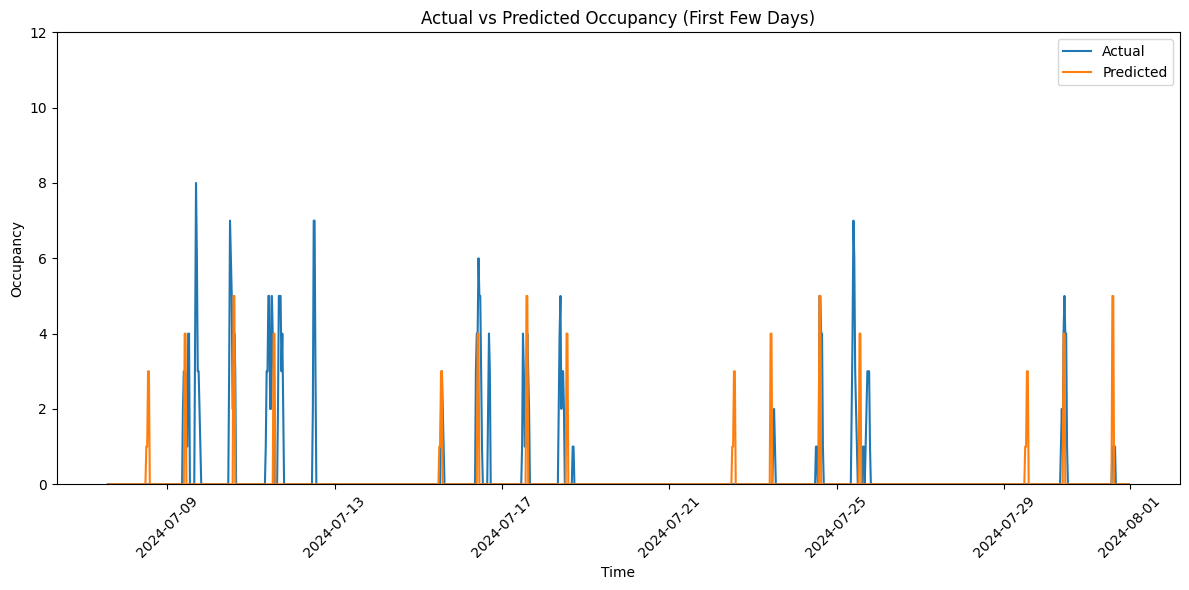

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(t_plot, y_test_plot, label="Actual")
plt.plot(t_plot, y_pred_plot, label="Predicted")

plt.xlabel("Time")
plt.ylabel("Occupancy")
plt.title("Actual vs Predicted Occupancy (First Few Days)")
plt.legend()

plt.xticks(rotation=45)
plt.ylim(0, 12)  # for example
plt.tight_layout()
plt.show()